In [2]:
# Machine learning
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# For data manipulation
import pandas as pd
import numpy as np

# To plot
import matplotlib.pyplot as plt
# plt.style.use('seaborn-darkgrid')

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [17]:
# Read the csv file using read_csv
# method of pandas
df = pd.read_csv('../datasets/EURUSD_M1_LARGE_data.csv')
df

,time,open,high,low,close,tick_volume
0,2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29
1,2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28
2,2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25
3,2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15
4,2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16
...,...,...,...,...,...,...
28474,2024-12-04 05:18:00,1.04969,1.04978,1.04969,1.04977,19
28475,2024-12-04 05:19:00,1.04978,1.04979,1.04962,1.04965,26
28476,2024-12-04 05:20:00,1.04964,1.04971,1.04962,1.04962,28
28477,2024-12-04 05:21:00,1.04962,1.04969,1.04962,1.04963,17


In [19]:
# Changes The Date column as index columns
df.index = pd.to_datetime(df['time'])
df

# drop The original date column
df = df.drop(['time'], axis='columns')
df

,open,high,low,close,tick_volume
time,,,,,
2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29
2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28
2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25
2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15
2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16
...,...,...,...,...,...
2024-12-04 05:18:00,1.04969,1.04978,1.04969,1.04977,19
2024-12-04 05:19:00,1.04978,1.04979,1.04962,1.04965,26
2024-12-04 05:20:00,1.04964,1.04971,1.04962,1.04962,28


In [21]:
# Create predictor variables
df['Open-Close'] = df.open - df.close
df['High-Low'] = df.high - df.low

# Store all predictor variables in a variable X
X = df[['Open-Close', 'High-Low']]
X.head()

,Open-Close,High-Low
time,,
2024-11-04 05:23:00,-0.00005,0.00007
2024-11-04 05:24:00,0.00004,0.00008
2024-11-04 05:25:00,0.00006,0.00009
2024-11-04 05:26:00,0.00005,0.00005
2024-11-04 05:27:00,-0.00004,0.00008


In [22]:
# Target variables
y = np.where(df['close'].shift(-1) > df['close'], 1, 0)
y

array([0, 0, 0, ..., 1, 0, 0])

In [23]:
split_percentage = 0.8
split = int(split_percentage*len(df))

# Train data set
X_train = X[:split]
y_train = y[:split]

# Test data set
X_test = X[split:]
y_test = y[split:]

In [24]:
# Support vector classifier
cls = SVC().fit(X_train, y_train)

In [25]:
df['Predicted_Signal'] = cls.predict(X)

In [27]:
# Calculate daily returns
df['Return'] = df.close.pct_change()

In [28]:
# Calculate strategy returns
df['Strategy_Return'] = df.Return *df.Predicted_Signal.shift(1)

In [29]:
# Calculate Cumulutive returns
df['Cum_Ret'] = df['Return'].cumsum()
df

,open,high,low,close,tick_volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret
time,,,,,,,,,,,
2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29,-0.00005,0.00007,0,NaN,NaN,NaN
2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28,0.00004,0.00008,0,-0.000018,-0.0,-0.000018
2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25,0.00006,0.00009,0,-0.000046,-0.0,-0.000064
2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15,0.00005,0.00005,0,-0.000046,-0.0,-0.000110
2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16,-0.00004,0.00008,0,0.000046,0.0,-0.000064
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-04 05:18:00,1.04969,1.04978,1.04969,1.04977,19,-0.00008,0.00009,0,0.000076,0.0,-0.037272
2024-12-04 05:19:00,1.04978,1.04979,1.04962,1.04965,26,0.00013,0.00017,0,-0.000114,-0.0,-0.037386
2024-12-04 05:20:00,1.04964,1.04971,1.04962,1.04962,28,0.00002,0.00009,0,-0.000029,-0.0,-0.037415


In [30]:
# Plot Strategy Cumulative returns
df['Cum_Strategy'] = df['Strategy_Return'].cumsum()
df

,open,high,low,close,tick_volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
time,,,,,,,,,,,,
2024-11-04 05:23:00,1.08997,1.09002,1.08995,1.09002,29,-0.00005,0.00007,0,NaN,NaN,NaN,NaN
2024-11-04 05:24:00,1.09004,1.09008,1.09000,1.09000,28,0.00004,0.00008,0,-0.000018,-0.0,-0.000018,0.000000
2024-11-04 05:25:00,1.09001,1.09004,1.08995,1.08995,25,0.00006,0.00009,0,-0.000046,-0.0,-0.000064,0.000000
2024-11-04 05:26:00,1.08995,1.08995,1.08990,1.08990,15,0.00005,0.00005,0,-0.000046,-0.0,-0.000110,0.000000
2024-11-04 05:27:00,1.08991,1.08995,1.08987,1.08995,16,-0.00004,0.00008,0,0.000046,0.0,-0.000064,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-04 05:18:00,1.04969,1.04978,1.04969,1.04977,19,-0.00008,0.00009,0,0.000076,0.0,-0.037272,0.021404
2024-12-04 05:19:00,1.04978,1.04979,1.04962,1.04965,26,0.00013,0.00017,0,-0.000114,-0.0,-0.037386,0.021404
2024-12-04 05:20:00,1.04964,1.04971,1.04962,1.04962,28,0.00002,0.00009,0,-0.000029,-0.0,-0.037415,0.021404


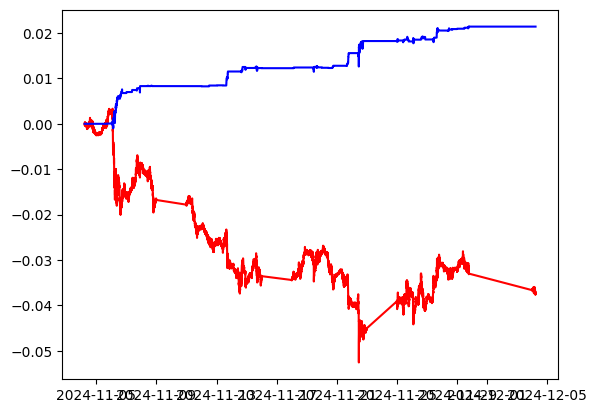

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(df['Cum_Ret'],color='red')
plt.plot(df['Cum_Strategy'],color='blue')